In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:

    sys.path.append(module_path)

In [2]:
import json
import numpy as np
import pandas as pd
import trackpy as tp
import seaborn as sns
import matplotlib.pyplot as plt

from cmcrameri import cm
from scipy.optimize import curve_fit

from src.FormatConversions import import_holomonitor_stack
from src.HolomonitorFunctions import get_pixel_size
from src.Correlations import spatial_autocorrelation, radial_distribution, pairwise_autocorrelation
from VertexModelFunctions import *

In [3]:
pix_to_um = get_pixel_size()
holo_dict = json.load(open("../../data/Holomonitor/settings.txt"))
colors = cm.roma_r(np.linspace(0, 1, len(holo_dict["files"])))

dataset = 1
path = holo_dict["files"][dataset]
fmin = holo_dict["fmin"][dataset]
fmax = holo_dict["fmax"][dataset]
file = path.split("/")[-1]
dir  = path.split(file)[0]

#stack = import_holomonitor_stack(dir, file, f_min=fmin, f_max=fmax)
df = pd.read_csv(f"{path}/area_volume_unfiltered.csv")
print(file)

A1-9


In [4]:
# initialize system
N_frames = np.max(df.frame)
max_dist = np.max([df.x, df.y]) + 1
if max_dist%2 == 0:
    max_dist += 1
    
dr = 1

In [5]:
# create array of distances
Lx = int(max_dist/2)
Ly = int(max_dist/2)
x = np.arange(-Lx,Lx+1,1) * pix_to_um[-2]
y = np.arange(-Ly,Ly+1,1) * pix_to_um[-1]
xx, yy = np.meshgrid(y, x)
rr = np.sqrt(xx**2. + yy**2.)

nbins = int((rr.max() / dr) + 1)
r_arr = np.zeros(nbins)
c_arr = np.zeros(nbins)

# count density of distance
for i in range(nbins):
    mask = (rr >= i*dr) * (rr < (i+1)*dr)
    r_arr[i] = np.mean(rr[mask])
    c_arr[i] = np.sum(mask)

In [6]:
# r_pairwise = []

# # go through all frames
# for t in range(N_frames+1):
#     # dataframe at time t
#     df_tmp  = df[df.frame==t]
#     tmp_arr = np.array([df_tmp['x'].values, df_tmp['y'].values])

#     # number of unique combinations
#     nn_max = int(np.ceil(len(tmp_arr.T) / 2))*2
#     for nn in range(1,nn_max-1):
#         roll_arr = np.roll(tmp_arr, shift=-nn, axis=1)
        
#         # calculate r_pairwise       
#         x_pos = np.array(tmp_arr[0] - roll_arr[0], dtype=int)
#         y_pos = np.array(tmp_arr[1] - roll_arr[1], dtype=int) 
#         tmp_r = np.sqrt(x_pos**2 + y_pos**2)*pix_to_um[1]

#         r_pairwise.append(tmp_r)

# r_pairwise= np.concatenate(r_pairwise)

# C_arr = np.zeros_like(r_arr)

# for i in range(len(r_arr)):
#     mask = (r_pairwise>= i*dr) * (r_pairwise< (i+1)*dr)
#     #if np.sum(mask) > 0:
#     C_arr[i] = np.sum(mask)


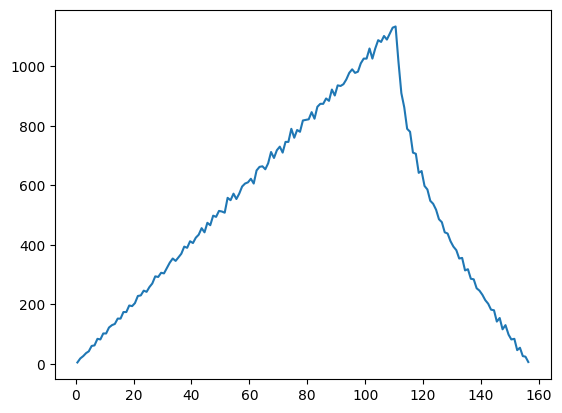

In [78]:
# create array of distances
max_dist = 401
Lx = int(max_dist/2)
Ly = int(max_dist/2)
x = np.arange(-Lx,Lx+1,1) * pix_to_um[-2]
y = np.arange(-Ly,Ly+1,1) * pix_to_um[-1]
xx, yy = np.meshgrid(y, x)
rr = np.sqrt(xx**2. + yy**2.)

nbins = int((rr.max() / dr) + 1)
r_arr = np.zeros(nbins)
c_arr = np.zeros(nbins)

# count density of distance
for i in range(nbins):
    mask = (rr >= i*dr) * (rr < (i+1)*dr)
    r_arr[i] = np.mean(rr[mask])
    c_arr[i] = np.sum(mask)

#plt.vlines(Lx*pix_to_um[0], 0, 6000, color="k")
plt.plot(r_arr, c_arr/2)

In [7]:
def pairCorrelationFunction_2D(x, y, S, rMax, dr):
    """Compute the two-dimensional pair correlation function, also known
    as the radial distribution function, for a set of circular particles
    contained in a square region of a plane.  This simple function finds
    reference particles such that a circle of radius rMax drawn around the
    particle will fit entirely within the square, eliminating the need to
    compensate for edge effects.  If no such particles exist, an error is
    returned. Try a smaller rMax...or write some code to handle edge effects! ;)

    Arguments:
        x               an array of x positions of centers of particles
        y               an array of y positions of centers of particles
        S               length of each side of the square region of the plane
        rMax            outer diameter of largest annulus
        dr              increment for increasing radius of annulus

    Returns a tuple: (g, radii, interior_indices)
        g(r)            a numpy array containing the correlation function g(r)
        radii           a numpy array containing the radii of the
                        annuli used to compute g(r)
        reference_indices   indices of reference particles
    """
    from numpy import zeros, sqrt, where, pi, mean, arange, histogram
    # Number of particles in ring/area of ring/number of reference particles/number density
    # area of ring = pi*(r_outer**2 - r_inner**2)

    # Find particles which are close enough to the box center that a circle of radius
    # rMax will not cross any edge of the box
    bools1 = x > rMax
    bools2 = x < (S - rMax)
    bools3 = y > rMax
    bools4 = y < (S - rMax)
    interior_indices, = where(bools1 * bools2 * bools3 * bools4)
    num_interior_particles = len(interior_indices)

    if num_interior_particles < 1:
        raise  RuntimeError ("No particles found for which a circle of radius rMax\
                will lie entirely within a square of side length S.  Decrease rMax\
                or increase the size of the square.")

    edges = arange(0., rMax + 1.1 * dr, dr)
    num_increments = len(edges) - 1
    g = zeros([num_interior_particles, num_increments])
    radii = zeros(num_increments)
    numberDensity = len(x) / S**2

    # Compute pairwise correlation for each interior particle
    for p in range(num_interior_particles):
        index = interior_indices[p]
        d = sqrt((x[index] - x)**2 + (y[index] - y)**2)
        d[index] = 2 * rMax

        (result, bins) = histogram(d, bins=edges, density=False)
        g[p, :] = result/numberDensity

    # Average g(r) for all interior particles and compute radii
    g_average = zeros(num_increments)
    for i in range(num_increments):
        radii[i] = (edges[i] + edges[i+1]) / 2.
        rOuter = edges[i + 1]
        rInner = edges[i]
        g_average[i] = mean(g[:, i]) / (pi * (rOuter**2 - rInner**2))

    return (g_average, radii, interior_indices)

In [27]:
dataset = 5
path = holo_dict["files"][dataset]
fmin = holo_dict["fmin"][dataset]
fmax = holo_dict["fmax"][dataset]
file = path.split("/")[-1]
dir  = path.split(file)[0]

#stack = import_holomonitor_stack(dir, file, f_min=fmin, f_max=fmax)
df = pd.read_csv(f"{path}/area_volume_unfiltered.csv")

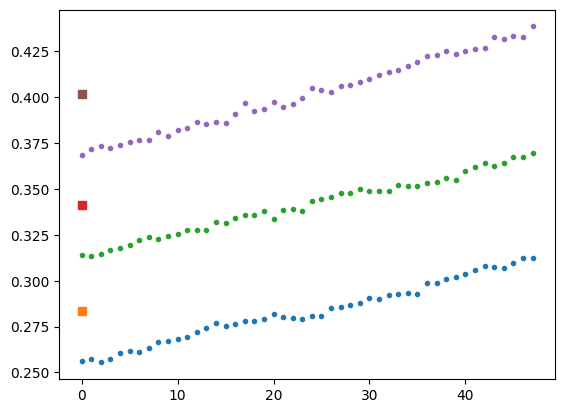

In [28]:
x = df[df.frame==1].x.values
y = df[df.frame==1].y.values
S = 1004
rMax = 200
dr = 2
steps = 3
size = int(np.max(df.frame)/steps)

g_r, radius = [], []
label = []
for i in range(steps):
    g_tmp = []
    r_tmp = []

    for t in range(i*size, (i+1)*size):
        # dataframe at time t
        df_tmp  = df[df.frame==t]
        x, y = df_tmp['x'].values, df_tmp['y'].values

        g_t, r_t, _ = pairCorrelationFunction_2D(x, y, S, rMax, dr)

        g_tmp.append(g_t)
        r_tmp.append(hexagon_area(np.mean(df_tmp.V.values)) / np.mean(df_tmp.A.values))

    plt.plot(r_tmp, '.')
    plt.plot(np.mean(r_tmp), 's')

    g_r.append(np.mean(g_tmp, axis=0))
    label.append(np.round(np.mean(r_tmp), 2))
    

radius = pix_to_um[0] * r_t

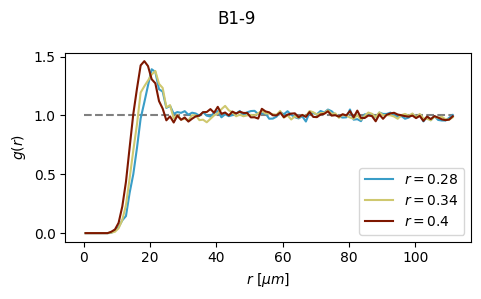

In [29]:
fig, ax = plt.subplots(1,1, figsize=(5,3))
fig.suptitle(path.split("/")[-1])
ax.hlines(1, 0, np.max(radius), linestyle="dashed", color="gray")
colors = cm.roma_r(np.linspace(0.25,1,steps))

for i in range(steps):
    scale = np.mean(g_r[i][40:])
    ax.plot(radius, g_r[i] / scale, label=r"$r=$"+str(label[i]), color=colors[i])

ax.set(xlabel=r"$r~[µm]$", ylabel=r"$g(r)$");
ax.legend()
fig.tight_layout()

In [107]:
fig.savefig(f"../../figs/vertex_model/g_r_{path.split('/')[-1]}.png", dpi=300)

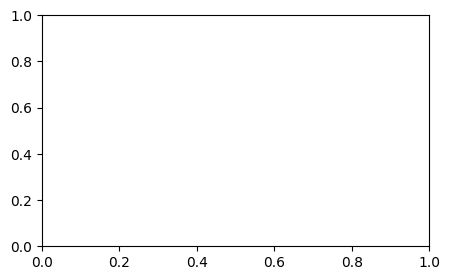

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(5,3))

In [12]:
dataset = 4
fmin=holo_dict['fmin'][dataset]
fmax=holo_dict['fmax'][dataset]
holo_file = holo_dict['files'][dataset].split("/")[-1]
holo_dir  = holo_dict['files'][dataset].split(holo_file)[0]

stack = import_holomonitor_stack(holo_dir, holo_file, f_min=fmin, f_max=fmax)

In [13]:
C_hh = []
for t in range(len(stack)):
    #var = np.mean(stack[t]**2) - np.mean(im)**2
    im = stack[t][:981, :981]
    im  = (im - np.mean(im)) #/ np.sqrt(var)
    im_corr = spatial_autocorrelation(im)

    dist, mean, _ = radial_distribution(im_corr, pix_to_um)
    C_hh.append(mean)

r_hh = dist * pix_to_um[0]
C_hh = np.mean(C_hh, axis=0)

In [ ]:
# r_hh = dist * pix_to_um[0]
# C_hh = np.mean(C_hh, axis=0)
def func(x, b):
    return np.exp(-x / b)

param, popt = curve_fit(func, r_hh, C_hh/C_hh[0])

ax.plot(r_hh, C_hh / C_hh[0], c=colors[dataset]) #, label=holo_file)
ax.plot(r_hh, func(r_hh, *param))

fig
param

array([1.09203236, 0.98048811])

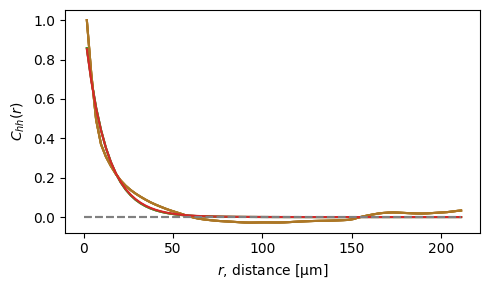

In [54]:
ax.hlines(0, 0, np.max(r_hh), linestyle="dashed", color="gray")
ax.set(xlabel=r"$r$, distance [µm]", ylabel=r"$C_{hh}(r)$");
fig.tight_layout()
fig

In [100]:
fig.savefig(f"../../figs/vertex_model/C_hh.png", dpi=300)

In [102]:
dataset = 0
file = holo_dict["files"][dataset]
df = pd.read_csv(f"{file}/area_volume_filtered.csv")

# track cells
tracks_raw = tp.link(df, search_range=10, memory=5)
tracks = tp.filter_stubs(tracks_raw, 5)
tracks = tracks.reset_index(drop=True)

Frame 37: 684 trajectories present.


In [120]:
# Subtract trend from volume
std_V  = 0
tracks['dr'] = {}


for p in np.unique(tracks.particle):
    df_tmp = tracks[tracks.particle == p]

    dx = np.diff(df_tmp['x'].values)
    dy = np.diff(df_tmp['y'].values)
    dr = np.concatenate([[0], np.sqrt(dx**2 + dy**2)]) * pix_to_um[0]

    tracks.loc[tracks['particle']==p, 'dr'] = dr # - np.mean(dr)

for t in range(np.max(tracks.frame)+1):
    df_tmp = tracks[tracks.frame == t]
    tracks.loc[tracks['frame']==t, 'dr'] = df_tmp.dr - np.mean(df_tmp.dr) 


In [121]:
r_arr, C_arr = pairwise_autocorrelation(tracks, 'dr', pix_to_um)

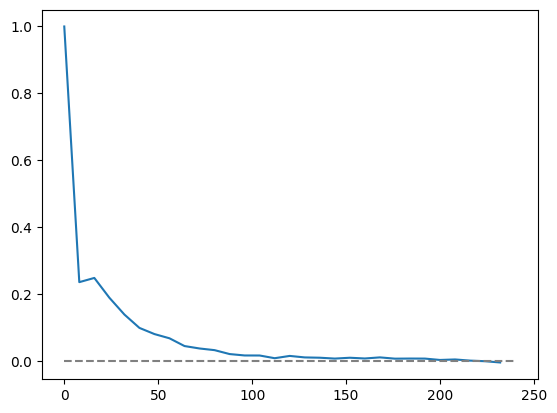

In [132]:
idx = 30
plt.plot(r_arr[:idx], C_arr[:idx] / C_arr[0], '-')
plt.hlines(0, 0, r_arr[idx], linestyles="dashed", color="gray")